# Vocabulary Level Prediction

## 0. Enviorment Setting

In [1]:
import importlib
import pandas as pd
import matplotlib.pyplot as plt
import utils
importlib.reload(utils)  # Pick up changes to utils.py without restarting the kernel
from utils import (
    load_data,
    apply_preprocessing_to_dataframe,
    get_missing_counts,
    get_target_value_counts,
    compute_rater_agreement,
    plot_target_distributions_side_by_side,
    plot_absolute_difference_distribution,
    get_text_length_features_df,
    get_length_features_summary,
    plot_length_distributions,
    get_length_target_correlations,
    plot_length_target_heatmap,
    get_vocabulary_richness_df,
    get_richness_features_summary,
    plot_richness_distributions,
    get_top_n_words_corpus,
    get_top_n_words_per_score_group,
)

# Show full column content when displaying DataFrames
pd.set_option("display.max_colwidth", None)

## 1. Preprocessing

In [2]:
# Read vocabulary dataset (text_id, Text, vocabulary1, vocabulary2)
df = pd.read_csv("vocabulary_data.csv")

# Show a few rows with Text column in full (no truncation)
pd.set_option("display.max_colwidth", None)
# df.head(5)

In [3]:
# Apply preprocessing (normalize whitespace, lowercase, strip punctuation keep . ? !)
df = apply_preprocessing_to_dataframe(df, "Text", output_column="Text_cleaned")
# df[["text_id", "Text_cleaned", "Vocabulary_1", "Vocabulary_2"]].head(5)

## 2. EDA

### 2.1 Basic statistics and target definition

In [4]:
# Missing values per column
get_missing_counts(df)

text_id         2408
Text               0
Vocabulary_1       0
Vocabulary_2       0
Text_cleaned       0
dtype: int64

In [5]:
# Target distributions (Vocabulary_1, Vocabulary_2)
get_target_value_counts(df, "Vocabulary_1")

Vocabulary_1
0      18
1      23
2    1032
3    4798
4    2666
5     353
Name: count, dtype: int64

In [6]:
get_target_value_counts(df, "Vocabulary_2")

Vocabulary_2
0      18
1      28
2    1075
3    4888
4    2558
5     323
Name: count, dtype: int64

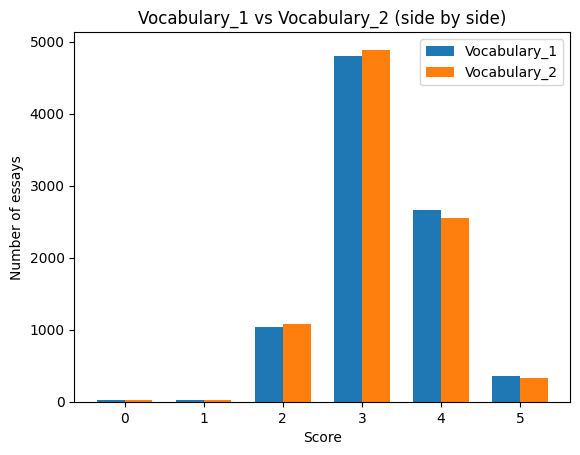

In [7]:
# Target distributions side by side (Vocabulary_1 vs Vocabulary_2 per score 0-5)
plot_target_distributions_side_by_side(df, "Vocabulary_1", "Vocabulary_2")
plt.show()

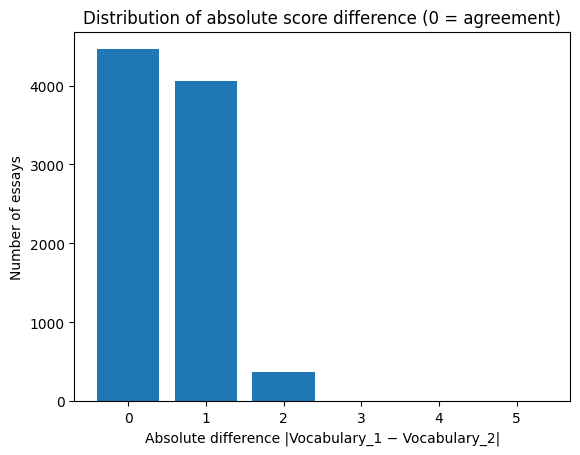

In [8]:
# Distribution of absolute score difference (0 = agreement, 1-5 = disagreement)
plot_absolute_difference_distribution(df, "Vocabulary_1", "Vocabulary_2")
plt.show()

In [9]:
# V1 vs V2 scatter
# Rater agreement: weighted kappa, exact agreement %, Spearman correlation
compute_rater_agreement(df, "Vocabulary_1", "Vocabulary_2")

{'weighted_kappa': 0.41302498999822634,
 'exact_agreement_pct': np.float64(50.168728908886386),
 'spearman_corr': np.float64(0.3835405049532997)}

### 2.2 Text length analysis

In [10]:
# Per-essay length features from Text_cleaned (char, word, sentence count, avg word length)
length_features = get_text_length_features_df(df, "Text_cleaned")

get_length_features_summary(length_features)

,char_count,word_count,sentence_count,avg_word_length
mean,2280.948594,429.781665,18.654781,4.326155
std,1038.493680,197.583791,10.577771,0.565530
min,1.000000,1.000000,1.000000,1.000000
25%,1532.000000,288.000000,11.000000,4.118522
50%,2128.000000,400.000000,17.000000,4.306803
75%,2828.000000,530.000000,25.000000,4.504405
max,6080.000000,1274.000000,114.000000,42.666667


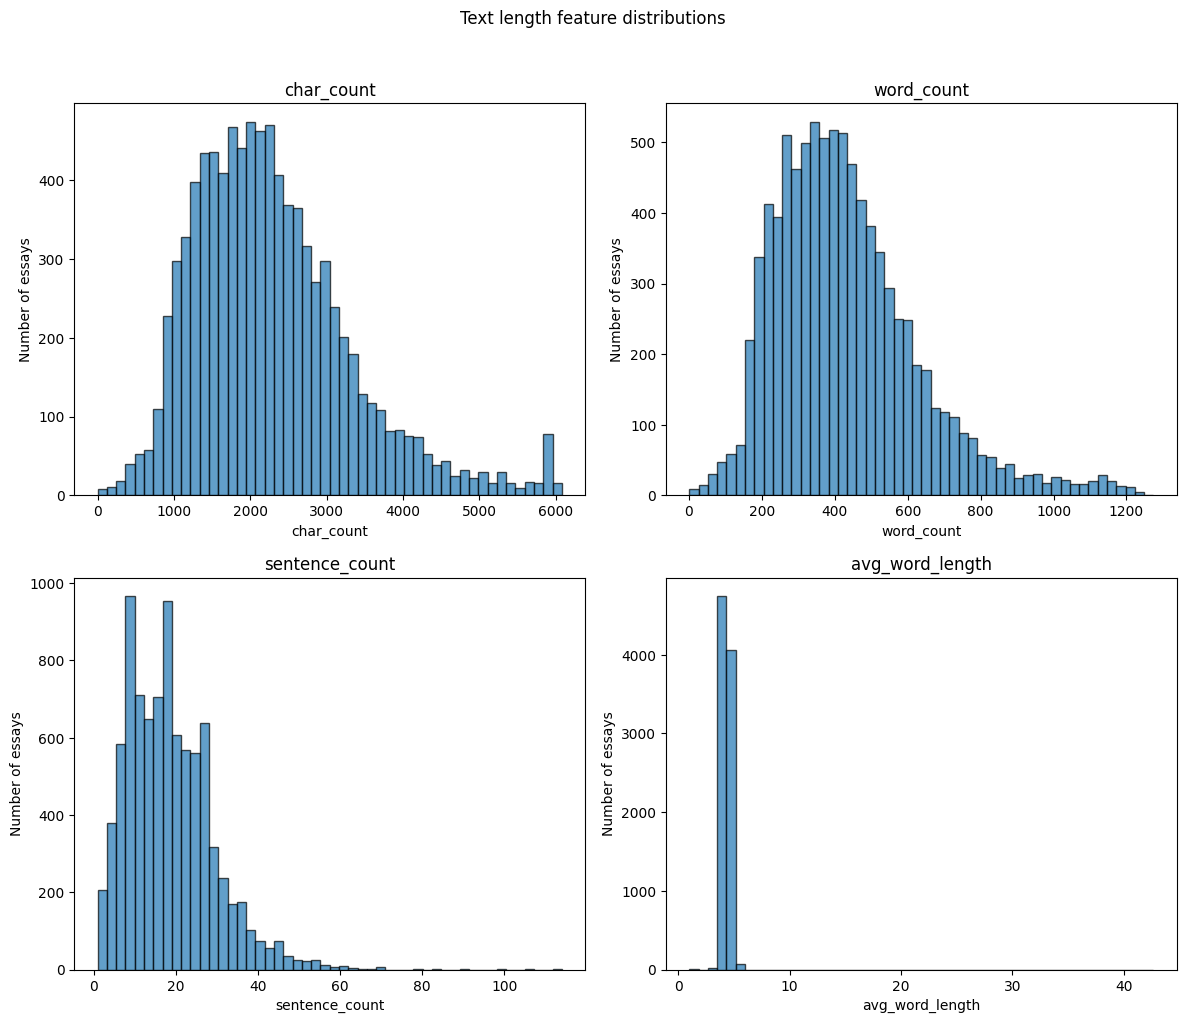

In [11]:
# Distributions of length features (histograms)
plot_length_distributions(length_features)
plt.show()

In [12]:
# Spearman correlation of each length feature with Vocabulary_1 and Vocabulary_2
get_length_target_correlations(length_features, df["Vocabulary_1"], method="spearman")
get_length_target_correlations(length_features, df["Vocabulary_2"], method="spearman")

char_count         0.280782
word_count         0.259081
sentence_count     0.285010
avg_word_length    0.193254
dtype: float64

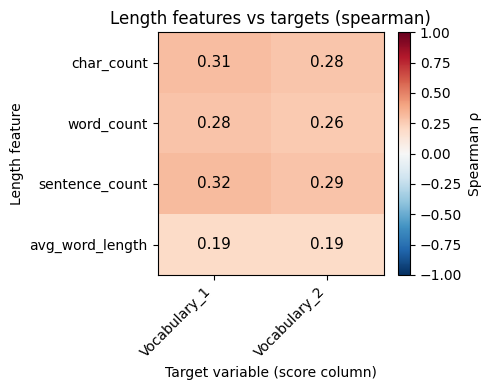

In [13]:
# Heatmap: length features vs target columns (Spearman)
plot_length_target_heatmap(length_features, ["Vocabulary_1", "Vocabulary_2"], df, method="spearman")
plt.tight_layout()
plt.show()

### 2.3 Vocabulary richness

In [14]:
# Per-essay vocabulary richness (unique words, TTR, hapax ratio); . ? ! stripped on demand
richness_features = get_vocabulary_richness_df(df, "Text_cleaned")
get_richness_features_summary(richness_features)

,unique_words,ttr,hapax_ratio
mean,151.873791,0.378933,0.539200
std,53.380604,0.086327,0.077812
min,0.000000,0.000000,0.000000
25%,113.000000,0.319958,0.490385
50%,145.000000,0.371780,0.538824
75%,182.750000,0.430615,0.588235
max,410.000000,1.000000,1.000000


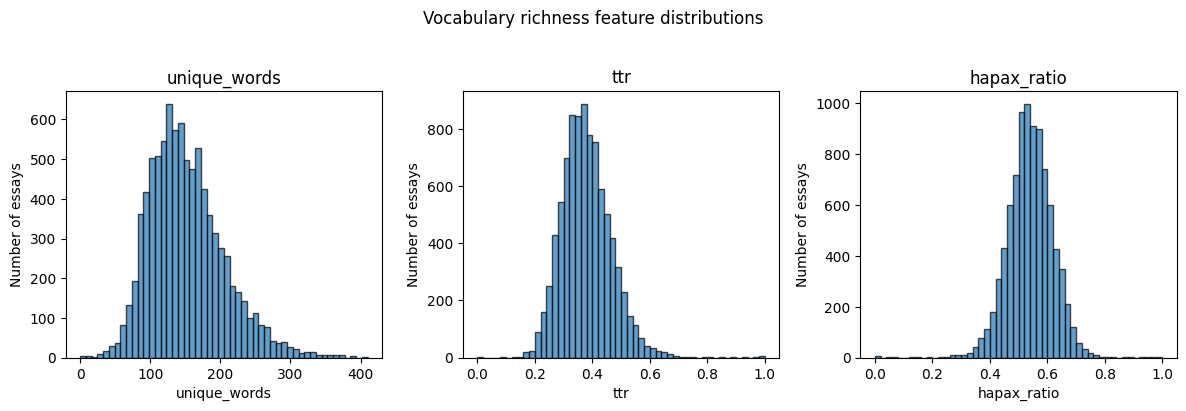

In [15]:
# Distributions of richness features
plot_richness_distributions(richness_features)
plt.show()

In [16]:
# Spearman correlation of each richness feature with Vocabulary_1 and Vocabulary_2
get_length_target_correlations(richness_features, df["Vocabulary_1"], method="spearman")
get_length_target_correlations(richness_features, df["Vocabulary_2"], method="spearman")

unique_words    0.339769
ttr             0.001420
hapax_ratio     0.074807
dtype: float64

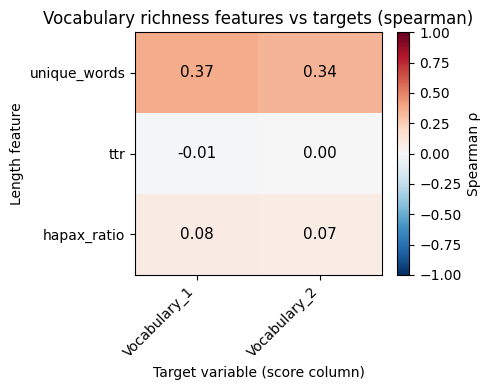

In [17]:
# Heatmap: richness features vs target columns (Spearman)
plot_length_target_heatmap(richness_features, ["Vocabulary_1", "Vocabulary_2"], df, method="spearman", title="Vocabulary richness features vs targets (spearman)")
plt.tight_layout()
plt.show()

### 2.4 Word frequency

In [18]:
# Top 30 words in the corpus (stopwords removed)
top_30_corpus = get_top_n_words_corpus(df["Text_cleaned"], n=10)
top_30_corpus

you         85834
i           53963
can         41259
people      34523
do          31784
students    30060
school      28229
we          25799
your        24460
their       23990
dtype: int64

In [20]:
# Top 30 words per Vocabulary_1 score (0–5); stopwords removed
top_per_score = get_top_n_words_per_score_group(
    df, "Text_cleaned", "Vocabulary_1", n=10
)
for score in sorted(top_per_score.keys()):
    print(f"--- Score {score} ---")
    display(top_per_score[score])

--- Score 0 ---


que       76
i         57
dont      32
de        27
my        25
music     24
para      23
church    23
me        21
you       20
dtype: int64

--- Score 1 ---


you        96
i          75
good       54
school     52
work       48
need       46
think      45
student    42
can        41
class      41
dtype: int64

--- Score 2 ---


...

you         46722
i           28099
can         22581
people      18231
do          17393
students    15169
school      14988
we          14056
your        13133
their       11474
dtype: int64

--- Score 4 ---


you         27258
i           17416
can         12632
people      11091
students    11076
do           9765
their        9450
school       9329
your         8033
we           7810
dtype: int64

--- Score 5 ---


you         2900
i           2705
can         1761
students    1636
people      1540
their       1528
school      1237
do          1206
my          1081
we          1003
dtype: int64